In [1]:
!pip install pandas sqlalchemy


In [2]:
import zipfile, os
import pandas as pd
from sqlalchemy import create_engine

def normalize_columns(df):
    df = df.rename(columns=lambda c: c.strip())
    mapping = {
        'Timestamp': 'timestamp',
        'Sensor_ID': 'sensor_id',
        'Pressure (bar)': 'pressure_bar',
        'Flow Rate (L/s)': 'flow_rate_lps',
        'Temperature (°C)': 'temperature_c',
        'Leak Status': 'leak_status',
        'Burst Status': 'burst_status'
    }
    present_mapping = {k:v for k,v in mapping.items() if k in df.columns}
    df = df.rename(columns=present_mapping)
    return df

def coerce_labels(df):
    for col in ['leak_status','burst_status']:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().str.lower()
            df[col] = df[col].map({
                '1':1,'0':0,'yes':1,'no':0,'true':1,'false':0,
                'y':1,'n':0,'on':1,'off':0
            }).fillna(0).astype(int)
    return df

def load_zip_to_dataframe(zip_path):
    dfs=[]
    with zipfile.ZipFile(zip_path,'r') as z:
        csv_files=[n for n in z.namelist() if n.lower().endswith('.csv')]
        for fname in csv_files:
            print("Reading",fname)
            with z.open(fname) as f:
                df=pd.read_csv(f)
                df=normalize_columns(df)
                df=coerce_labels(df)
                if 'timestamp' in df.columns:
                    df['timestamp']=pd.to_datetime(df['timestamp'],errors='coerce')
                dfs.append(df)
    return pd.concat(dfs,ignore_index=True)

#run
zip_path = '/content/water_leak_dataset.zip'
df = load_zip_to_dataframe(zip_path)

print("Shape:",df.shape)
print(df.head())

print("\nMissing values:")
print(df.isnull().sum())

if 'timestamp' in df.columns:
    print("\nTimestamp range:",df['timestamp'].min(),"to",df['timestamp'].max())
if 'sensor_id' in df.columns:
    print("Unique sensors:",df['sensor_id'].nunique())

for col in ['leak_status','burst_status']:
    if col in df.columns:
        print(f"{col} counts:\n",df[col].value_counts())

# Saving to SQLite
os.makedirs('/content/data',exist_ok=True)
engine=create_engine("sqlite:////content/data/water_readings.db")
df.to_sql('raw_water_readings',engine,if_exists='replace',index=False)
print("\nSaved to /content/data/water_readings.db")

#dictionary
checks={
    "rows":len(df),
    "cols":df.columns.tolist(),
    "start_ts":str(df['timestamp'].min()) if 'timestamp' in df.columns else None,
    "end_ts":str(df['timestamp'].max()) if 'timestamp' in df.columns else None,
    "unique_sensors":int(df['sensor_id'].nunique()) if 'sensor_id' in df.columns else None,
    "leak_count":int(df['leak_status'].sum()) if 'leak_status' in df.columns else None,
    "burst_count":int(df['burst_status'].sum()) if 'burst_status' in df.columns else None,
}
print("\n--- Paste these results back ---")
import json
print(json.dumps(checks,indent=2))


Reading water_leak_detection_1000_rows.csv
Shape: (1000, 7)
            timestamp sensor_id  pressure_bar  flow_rate_lps  temperature_c  \
0 2024-01-01 00:00:00      S007      3.694814      77.515218      21.695365   
1 2024-01-01 00:05:00      S007      2.587125     179.926422      19.016725   
2 2024-01-01 00:10:00      S002      2.448965     210.130823      10.011681   
3 2024-01-01 00:15:00      S009      2.936844     141.777934      12.092408   
4 2024-01-01 00:20:00      S003      3.073693     197.484633      17.001443   

   leak_status  burst_status  
0            0             0  
1            0             0  
2            1             0  
3            0             0  
4            0             0  

Missing values:
timestamp        0
sensor_id        0
pressure_bar     0
flow_rate_lps    0
temperature_c    0
leak_status      0
burst_status     0
dtype: int64

Timestamp range: 2024-01-01 00:00:00 to 2024-01-04 11:15:00
Unique sensors: 10
leak_status counts:
 leak_status
0  

In [3]:
import pandas as pd
from sqlalchemy import create_engine

# Load raw data from SQLite
engine = create_engine("sqlite:////content/data/water_readings.db")
df = pd.read_sql("SELECT * FROM raw_water_readings", engine, parse_dates=['timestamp'])

# Sort by sensor and timestamp
df = df.sort_values(['sensor_id','timestamp']).reset_index(drop=True)

# Compute interval in seconds per sensor
df['prev_timestamp'] = df.groupby('sensor_id')['timestamp'].shift(1)
df['time_diff_s'] = (df['timestamp'] - df['prev_timestamp']).dt.total_seconds()
df['time_diff_s'] = df['time_diff_s'].fillna(0)  # first record per sensor


# SCALING FLOW RATE TO REALISTIC VALUES
# Typical urban household/sensor flows: 0.001–0.01 L/s per tap
scaling_factor = 0.001
df['flow_rate_lps'] = df['flow_rate_lps'] * scaling_factor

# Compute volume in liters (Flow Rate L/s * interval seconds)
df['volume_l'] = df['flow_rate_lps'] * df['time_diff_s']

# Compute overnight flag (0–6 AM)
df['hour'] = df['timestamp'].dt.hour
df['is_overnight'] = df['hour'].apply(lambda x: 1 if 0 <= x < 6 else 0)

# Rolling features (last 3 readings as example)
df['rolling_volume_mean_3'] = df.groupby('sensor_id')['volume_l'].rolling(3, min_periods=1).mean().reset_index(0,drop=True)
df['rolling_pressure_mean_3'] = df.groupby('sensor_id')['pressure_bar'].rolling(3, min_periods=1).mean().reset_index(0,drop=True)
df['rolling_temp_mean_3'] = df.groupby('sensor_id')['temperature_c'].rolling(3, min_periods=1).mean().reset_index(0,drop=True)

# Save processed data to SQLite
df.to_sql('processed_water_readings', engine, if_exists='replace', index=False)
print("Saved processed features to SQLite table: processed_water_readings")

# Quick check
print("Processed data head:")
print(df.head())
print("\nTotal records:", len(df))
print("Columns:", df.columns.tolist())


Saved processed features to SQLite table: processed_water_readings
Processed data head:
            timestamp sensor_id  pressure_bar  flow_rate_lps  temperature_c  \
0 2024-01-01 01:10:00      S001      2.595338       0.096647      14.877750   
1 2024-01-01 02:20:00      S001      2.726076       0.126230      20.437192   
2 2024-01-01 02:30:00      S001      3.096358       0.127663      22.565652   
3 2024-01-01 05:15:00      S001      3.477227       0.081003      14.109417   
4 2024-01-01 05:45:00      S001      3.257879       0.173969      14.800744   

   leak_status  burst_status      prev_timestamp  time_diff_s    volume_l  \
0            0             0                 NaT          0.0    0.000000   
1            0             0 2024-01-01 01:10:00       4200.0  530.165229   
2            0             0 2024-01-01 02:20:00        600.0   76.597622   
3            0             0 2024-01-01 02:30:00       9900.0  801.926274   
4            0             0 2024-01-01 05:15:00    

In [4]:
import pandas as pd
from sqlalchemy import create_engine

# Load processed data
engine = create_engine("sqlite:////content/data/water_readings.db")
df = pd.read_sql("SELECT * FROM processed_water_readings", engine, parse_dates=['timestamp'])

def format_loss(loss):
    if loss >= 1e7:
        return f"{loss/1e7:.2f} Cr"
    elif loss >= 1e5:
        return f"{loss/1e5:.2f} L"
    else:
        return f"{loss:.2f} Rs"

def detect_leak_rule_based(df_sensor, overnight_hours=6, threshold_liters=50, unit_cost=0.05):
    """
    df_sensor: data for a single sensor
    overnight_hours: 0-6 AM
    threshold_liters: threshold to consider as leak (now realistic)
    unit_cost: cost per liter (Rs)
    """
    overnight_df = df_sensor[df_sensor['is_overnight']==1]
    overnight_usage = overnight_df['volume_l'].sum()

    leak_detected = overnight_usage > threshold_liters
    estimated_loss = overnight_usage * unit_cost if leak_detected else 0
    leak_percentage = min((overnight_usage / threshold_liters) * 100, 100)  # cap at 100%

    msg = f"Potential leak detected: {overnight_usage:.2f} L overnight" if leak_detected else "No leak detected"

    return leak_detected, msg, estimated_loss, leak_percentage

# Check all sensors
results = []
for sensor in df['sensor_id'].unique():
    df_sensor = df[df['sensor_id']==sensor]
    leak, msg, loss, perc = detect_leak_rule_based(df_sensor)
    results.append({
        'sensor_id': sensor,
        'leak_detected': leak,
        'message': msg,
        'estimated_loss': format_loss(loss),
        'leak_percentage': round(perc,2)
    })

results_df = pd.DataFrame(results)
print(results_df)


  sensor_id  leak_detected                                        message  \
0      S001           True  Potential leak detected: 10746.58 L overnight   
1      S002           True   Potential leak detected: 7981.22 L overnight   
2      S003           True  Potential leak detected: 11156.71 L overnight   
3      S004           True   Potential leak detected: 8740.37 L overnight   
4      S005           True   Potential leak detected: 8000.19 L overnight   
5      S006           True   Potential leak detected: 8718.30 L overnight   
6      S007           True  Potential leak detected: 10801.73 L overnight   
7      S008           True  Potential leak detected: 10124.02 L overnight   
8      S009           True   Potential leak detected: 9635.24 L overnight   
9      S010           True   Potential leak detected: 9661.87 L overnight   

  estimated_loss  leak_percentage  
0      537.33 Rs              100  
1      399.06 Rs              100  
2      557.84 Rs              100  
3      4

In [5]:
#ML Simulation
from datetime import datetime, timedelta, timezone
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine("sqlite:////content/data/water_readings.db")
leak_history_db = []

def detect_leak_sim(user_id, threshold=50, unit_cost=0.05):
    sensor_ids = [f"S{user_id*1:03d}", f"S{user_id*1+1:03d}"]
    df_list = []
    for s_id in sensor_ids:
        df_sensor = pd.read_sql(f"""
            SELECT * FROM processed_water_readings
            WHERE sensor_id='{s_id}'
        """, engine, parse_dates=['timestamp'])
        if not df_sensor.empty:
            df_list.append(df_sensor)

    if not df_list:
        return False, "No data available for this user", 0.0

    df_all = pd.concat(df_list)
    overnight_df = df_all[df_all['is_overnight']==1]
    overnight_usage = overnight_df['volume_l'].sum()

    has_leak = overnight_usage > threshold
    estimated_loss = float(overnight_usage * unit_cost) if has_leak else 0.0
    message = f"Potential leak detected: {overnight_usage:.2f} L overnight" if has_leak else "No leak detected"

    now = datetime.now(timezone.utc)
    if has_leak:
        leak_history_db.append({
            'user_id': user_id,
            'date': now,
            'loss': estimated_loss,
            'message': message
        })

    return bool(has_leak), message, estimated_loss

# Test
user_id = 1
print(detect_leak_sim(user_id))


(True, 'Potential leak detected: 18727.80 L overnight', 936.3901185819925)


In [11]:
import pandas as pd

df = pd.read_csv('/content/water_leak_detection.csv')
print(df.columns.tolist())


['Timestamp', 'Sensor_ID', 'Pressure (bar)', 'Flow Rate (L/s)', 'Temperature (°C)', 'Leak Status', 'Burst Status']


In [12]:
!pip install requests
import requests, json


In [5]:
#Training Model and Saving for Backend

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

#Loading dataset
df = pd.read_csv('/content/water_leak_detection.csv')

# 2. Rename columns to remove spaces (optional, makes coding easier)
df.rename(columns={
    'Leak Status': 'leak_status',
    'Burst Status': 'burst_status',
    'Pressure (bar)': 'pressure_bar',
    'Flow Rate (L/s)': 'flow_rate_lps',
    'Temperature (°C)': 'temperature_c',
    'Sensor_ID': 'sensor_id',
    'Timestamp': 'timestamp'
}, inplace=True)

# 3. Define target column
target_col = 'leak_status'
y = df[target_col]

# 4. Drop target column to get features
X = df.drop(columns=[target_col])

# 5. Separate numeric and categorical columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# 6. Build preprocessing pipeline (scale numeric + one-hot encode categorical)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# 7. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 8. Build full pipeline with RandomForest
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# 9. Fit the pipeline
model.fit(X_train, y_train)

# 10. Save full pipeline as single .joblib
joblib.dump(model, 'leak_detection_model.joblib')
print("Full model pipeline saved as leak_detection_model.joblib")

# 11. Save original feature column names order
feature_columns = X.columns.to_numpy()
np.save('feature_columns.npy', feature_columns)
print("Feature columns saved as feature_columns.npy")

# 12. Quick test accuracy
accuracy = model.score(X_test, y_test) * 100
print(f"Quick accuracy check on test set: {accuracy:.2f}%")
print("- leak_detection_model.joblib (includes preprocessing and model)")
print("- feature_columns.npy (column order)")


Numeric columns: ['pressure_bar', 'flow_rate_lps', 'temperature_c', 'burst_status']
Categorical columns: ['timestamp', 'sensor_id']
Full model pipeline saved as leak_detection_model.joblib
Feature columns saved as feature_columns.npy
Quick accuracy check on test set: 99.50%
- leak_detection_model.joblib (includes preprocessing and model)
- feature_columns.npy (column order)


In [6]:
import joblib, numpy as np

pipeline = joblib.load('leak_detection_model.joblib')
feature_columns = np.load('feature_columns.npy', allow_pickle=True)


/tmp/ipython-input-3402798079.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="raise")


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.92      0.95       196
           1       0.11      0.50      0.18         4

    accuracy                           0.91       200
   macro avg       0.55      0.71      0.57       200
weighted avg       0.97      0.91      0.94       200

Balanced Accuracy: 0.7091836734693877
ROC-AUC Score: 0.913265306122449
Average Precision (AP): 0.5464285714285715


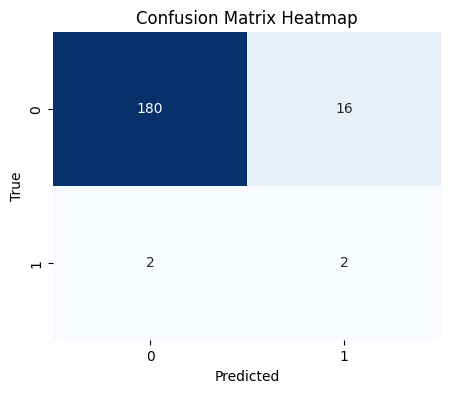

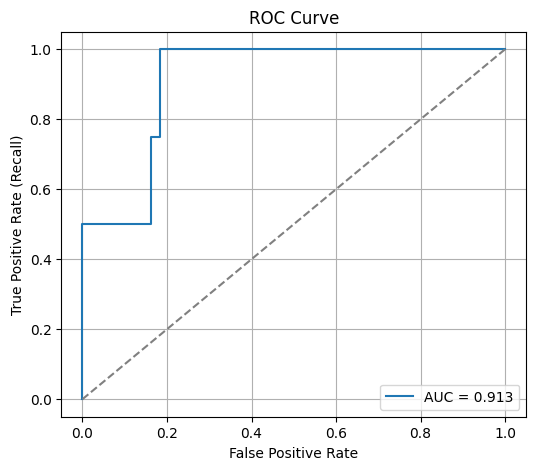

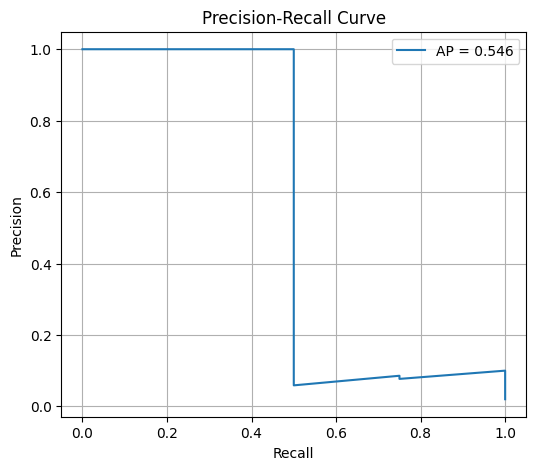

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, average_precision_score,
                             balanced_accuracy_score, roc_curve,
                             precision_recall_curve)

# STEP 1: Datetime preprocessing
def process_datetime_columns(df):
    df = df.copy()
    for col in df.columns:
        # Try to convert object/string columns to datetime
        if df[col].dtype == "object":
            try:
                df[col] = pd.to_datetime(df[col], errors="raise")
            except:
                continue  # leave non-datetime object columns as they are
        # If it’s datetime dtype, expand into numeric features
        if np.issubdtype(df[col].dtype, np.datetime64):
            df[f"{col}_year"] = df[col].dt.year
            df[f"{col}_month"] = df[col].dt.month
            df[f"{col}_day"] = df[col].dt.day
            df[f"{col}_hour"] = df[col].dt.hour
            df[f"{col}_weekday"] = df[col].dt.weekday
            df = df.drop(columns=[col])
    return df

# STEP 2: Apply preprocessing
X_processed = process_datetime_columns(X)

# Train-test split (stratified so minority class appears in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, stratify=y, random_state=42
)

# STEP 3: Identify numeric & categorical features
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

# STEP 4: Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# STEP 5: Pipeline
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

# Train
pipeline.fit(X_train, y_train)

# Predictions
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# STEP 6: Metrics
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))
print("Average Precision (AP):", average_precision_score(y_test, y_proba))

# STEP 7: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix Heatmap")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# STEP 9: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()
